In [23]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [24]:
class HeightData:
    def __init__(self, lowerpath, upperpath, VPPC):
        self.lowerpath = lowerpath
        self.upperpath = upperpath
        self.VPPC = VPPC
        self.loaddata()
    def loaddata(self):
        # Load and parse lowerpath
        lower_raw = np.loadtxt(self.lowerpath, skiprows=4)
        self.lowerdata = {
            'height': lower_raw[:, 0],
            'pixel': lower_raw[:, 1]
        }
        # Load and parse upperpath
        upper_raw = np.loadtxt(self.upperpath, skiprows=4)
        self.upperdata = {
            'height': upper_raw[:, 0],
            'pixel': upper_raw[:, 1]
        }
    def fitgauss(self):
        # Fit Gaussian to lowerdata
        self.lower_params, _ = sp.optimize.curve_fit(
            lambda x, a, mu, sigma: a * np.exp(-(x - mu)**2 / (2 * sigma**2)),
            self.lowerdata['height'], self.lowerdata['pixel'],
            p0=[np.max(self.lowerdata['pixel']), np.mean(self.lowerdata['height']), np.std(self.lowerdata['height'])],
            gtol=0.0001
        )
        # Fit Gaussian to upperdata
        self.upper_params, _ = sp.optimize.curve_fit(
            lambda x, a, mu, sigma: a * np.exp(-(x - mu)**2 / (2 * sigma**2)),
            self.upperdata['height'], self.upperdata['pixel'],
            p0=[np.max(self.upperdata['pixel']), np.mean(self.upperdata['height']), np.std(self.upperdata['height'])],
            gtol=0.0001
        )
        # Calculate difference in means and standard deviations (corrected)
        mean_diff = np.abs(self.lower_params[1] - self.upper_params[1])
        std_diff = np.abs(self.lower_params[2] - self.upper_params[2])
        self.meandiff = {'mean': mean_diff, 'std': std_diff}
        print(f"VPPC: {self.VPPC}, Mean Difference: {mean_diff}, Std Difference: {std_diff}")

    def savefigs(self):
        import os
        # Lower plot
        base_lower, _ = os.path.splitext(self.lowerpath)
        save_path_lower = base_lower + '_fit_lower.png'
        plt.figure(figsize=(6, 6))
        plt.scatter(self.lowerdata['height'], self.lowerdata['pixel'], label='Lower Data')
        plt.plot(self.lowerdata['height'], 
                 self.lower_params[0] * np.exp(-(self.lowerdata['height'] - self.lower_params[1])**2 / (2 * self.lower_params[2]**2)),
                 color='red', label='Lower Fit')
        plt.title('Lower Data Fit')
        plt.xlabel('Height')
        plt.ylabel('Pixel')
        plt.legend()
        plt.tight_layout()
        print(f"Saving lower figure to: {save_path_lower}")
        plt.savefig(save_path_lower, dpi=600)
        plt.close()

        # Upper plot
        base_upper, _ = os.path.splitext(self.upperpath)
        save_path_upper = base_upper + '_fit_upper.png'
        plt.figure(figsize=(6, 6))
        plt.scatter(self.upperdata['height'], self.upperdata['pixel'], label='Upper Data')
        plt.plot(self.upperdata['height'], 
                 self.upper_params[0] * np.exp(-(self.upperdata['height'] - self.upper_params[1])**2 / (2 * self.upper_params[2]**2)),
                 color='red', label='Upper Fit')
        plt.title('Upper Data Fit')
        plt.xlabel('Height')
        plt.ylabel('Pixel')
        plt.legend()
        plt.tight_layout()
        print(f"Saving upper figure to: {save_path_upper}")
        plt.savefig(save_path_upper, dpi=600)
        plt.close()

    def plotfit(self, savefig=False):
        # Plot lower data and fit
        fontsize16 = 16
        legendsize = 14
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.scatter(self.lowerdata['height'], self.lowerdata['pixel'], label='Lower Region Data')
        plt.plot(self.lowerdata['height'], 
                 self.lower_params[0] * np.exp(-(self.lowerdata['height'] - self.lower_params[1])**2 / (2 * self.lower_params[2]**2)),
                 color='red', label='Gaussian Fit')
        #plt.title('Lower Region', fontsize=fontsize16)
        plt.xlabel('Height (nm)', fontsize=fontsize16)
        plt.ylabel('Pixel', fontsize=fontsize16)
        plt.xticks(fontsize=fontsize16)
        plt.yticks(fontsize=fontsize16)
        plt.grid()
        plt.legend(fontsize=legendsize)
        # Plot upper data and fit
        plt.subplot(1, 2, 2)
        plt.scatter(self.upperdata['height'], self.upperdata['pixel'], label='Upper Region Data')
        plt.plot(self.upperdata['height'], 
                 self.upper_params[0] * np.exp(-(self.upperdata['height'] - self.upper_params[1])**2 / (2 * self.upper_params[2]**2)),
                 color='red', label='Gaussian Fit')
        #plt.title('Upper Region', fontsize = fontsize16)
        plt.xlabel('Height (nm)', fontsize=fontsize16)
        plt.ylabel('Pixel', fontsize=fontsize16)
        plt.xticks(fontsize=fontsize16)
        plt.yticks(fontsize=fontsize16)
        plt.grid()
        plt.legend(fontsize=legendsize)
        plt.tight_layout()
        plt.show()

    def process(self):
        self.fitgauss()
        self.plotfit()


In [25]:
PPCDATA = {
    '20_1': HeightData('daten/20_Lower_Region.txt', 'daten/20_Upper_Region_1.txt', '20'),
    '20_2': HeightData('daten/20_Lower_Region.txt', 'daten/20_Upper_Region_2.txt', '20'),
    '30_1': HeightData('daten/30_Lower_Region.txt', 'daten/30_Upper_Region_1.txt', '30'),
    '30_2': HeightData('daten/30_Lower_Region.txt', 'daten/30_Upper_Region_2.txt', '30'),
    '40_1': HeightData('daten/40_Lower_Region.txt', 'daten/40_Upper_Region_1.txt', '40'),
    '40_2': HeightData('daten/40_Lower_Region.txt', 'daten/40_Upper_Region_2.txt', '40'),
    '50_1': HeightData('daten/50_Lower_Region.txt', 'daten/50_Upper_Region_1.txt', '50'),
    '50_2': HeightData('daten/50_Lower_Region.txt', 'daten/50_Upper_Region_2.txt', '50'),
    '60_1': HeightData('daten/60_Lower_Region.txt', 'daten/60_Upper_Region_1.txt', '60'),
    '60_2': HeightData('daten/60_Lower_Region.txt', 'daten/60_Upper_Region_2.txt', '60'),
    '70_1': HeightData('daten/70_Lower_Region.txt', 'daten/70_Upper_Region_1.txt', '70'),
    '70_2': HeightData('daten/70_Lower_Region.txt', 'daten/70_Upper_Region_2.txt', '70'),
    '80_1': HeightData('daten/80_Lower_Region.txt', 'daten/80_Upper_Region_1.txt', '80'),
    '80_2': HeightData('daten/80_Lower_Region.txt', 'daten/80_Upper_Region_2.txt', '80'),
    '90_1': HeightData('daten/90_Lower_Region.txt', 'daten/90_Upper_Region_1.txt', '90'),
    '90_2': HeightData('daten/90_Lower_Region.txt', 'daten/90_Upper_Region_2.txt', '90')
}

VPPC: 20, Mean Difference: 3.3889825249728074, Std Difference: 0.4232935767452397


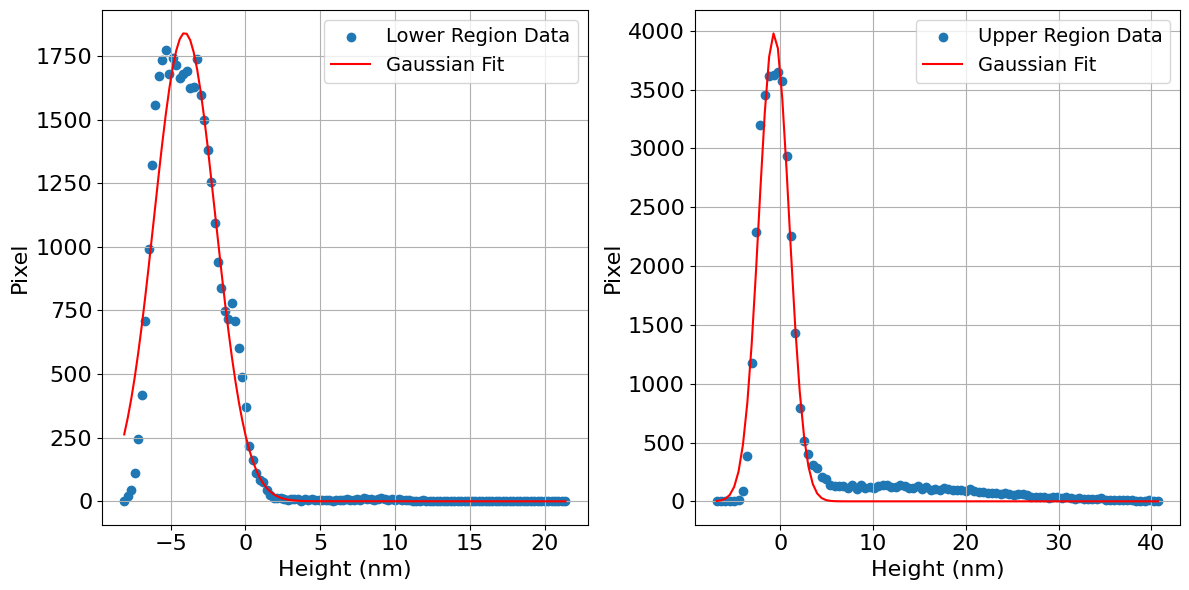

VPPC: 20, Mean Difference: 3.455640438011959, Std Difference: 0.3950226702101829


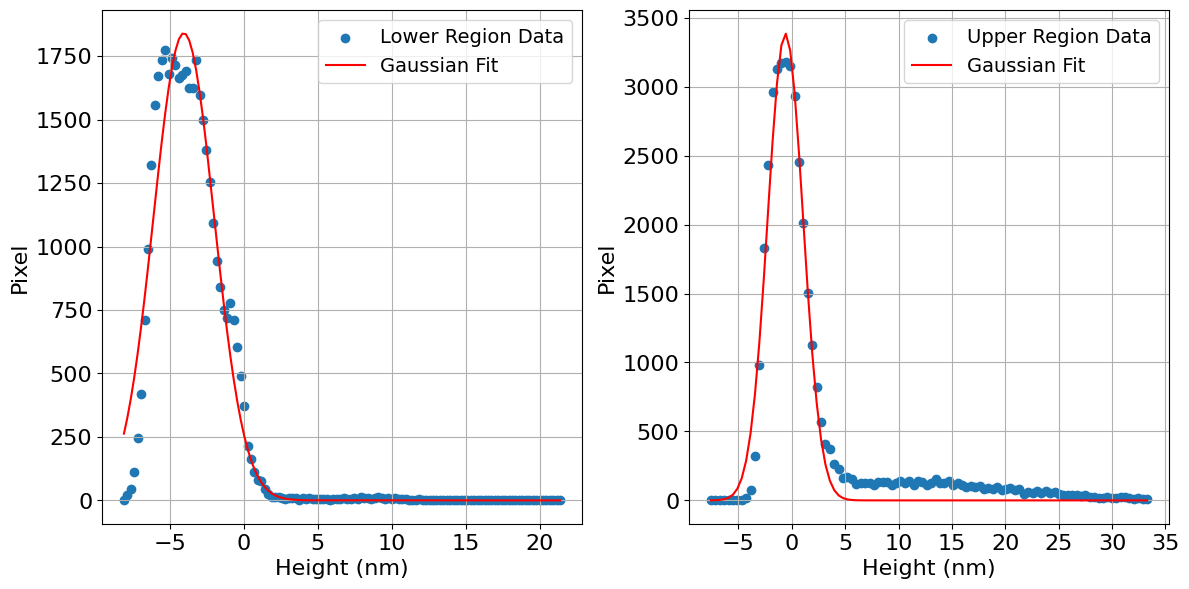

VPPC: 30, Mean Difference: 5.536972981992335, Std Difference: 0.2776430921810811


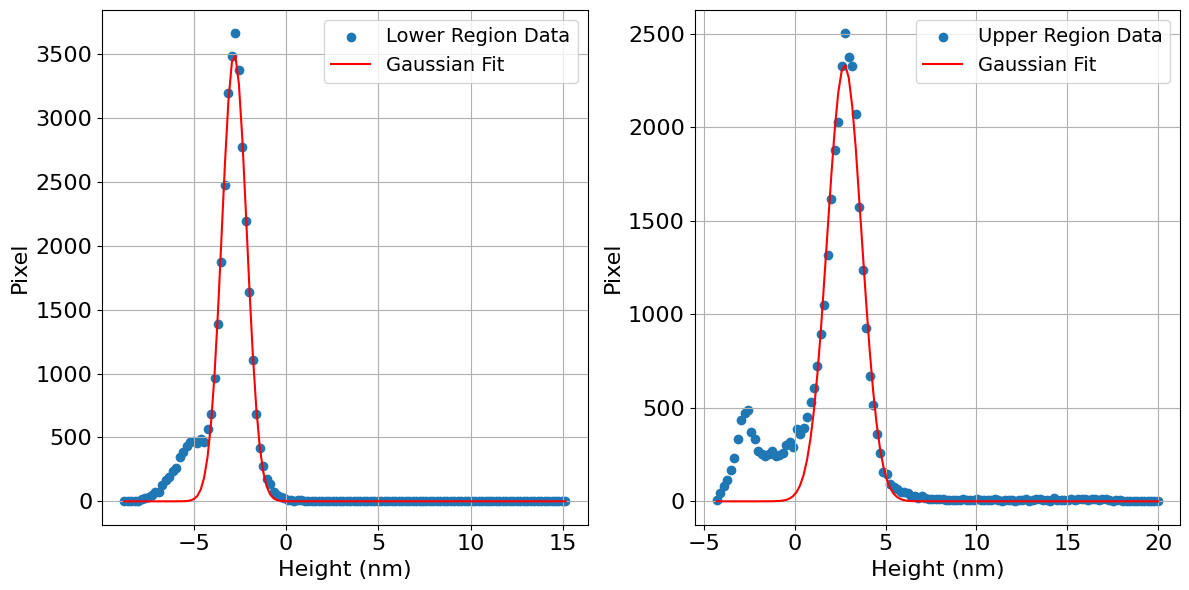

VPPC: 30, Mean Difference: 5.837988307906013, Std Difference: 0.4865362754387621


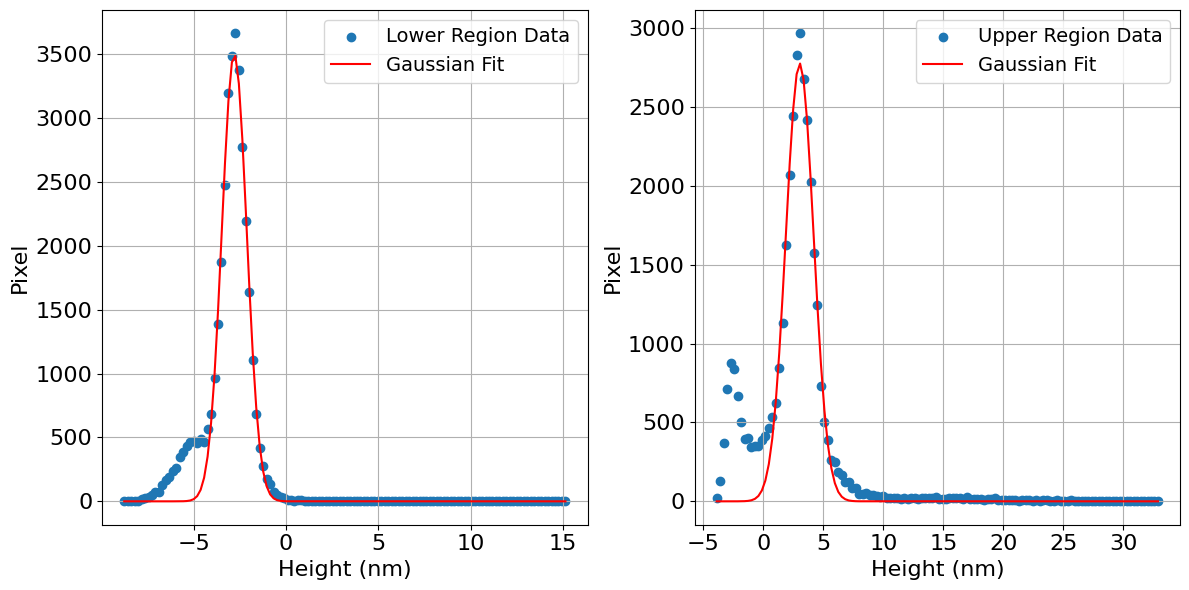

VPPC: 40, Mean Difference: 4.0471168066252945, Std Difference: 5.200044105771925


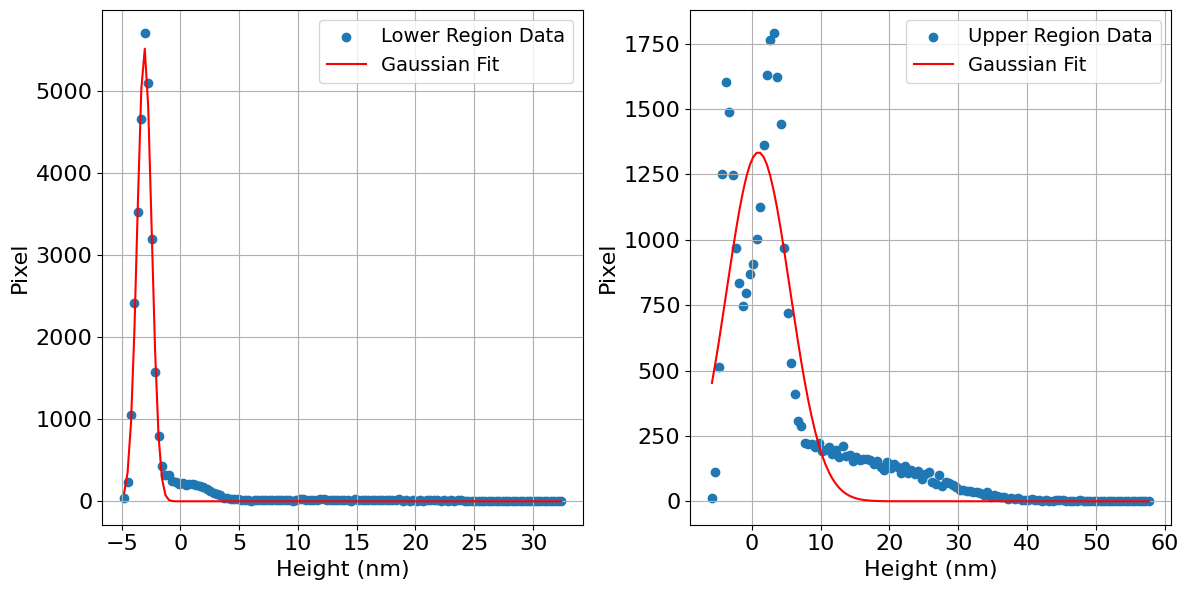

VPPC: 40, Mean Difference: 4.811767672163018, Std Difference: 5.2592260810240745


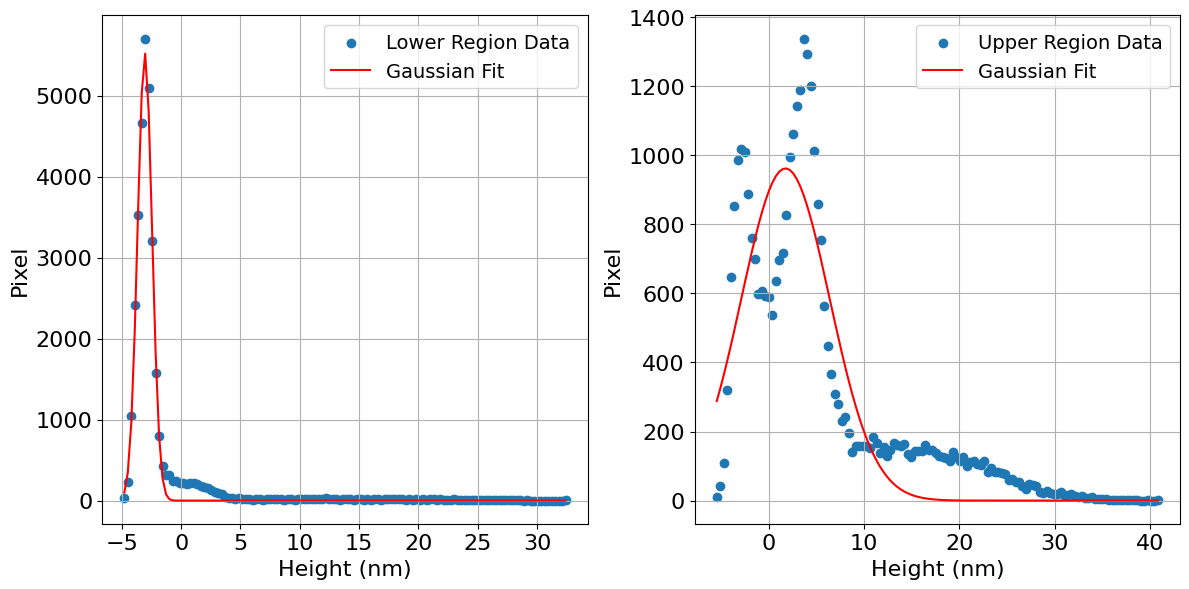

VPPC: 50, Mean Difference: 18.68770525779312, Std Difference: 4.34288349067552


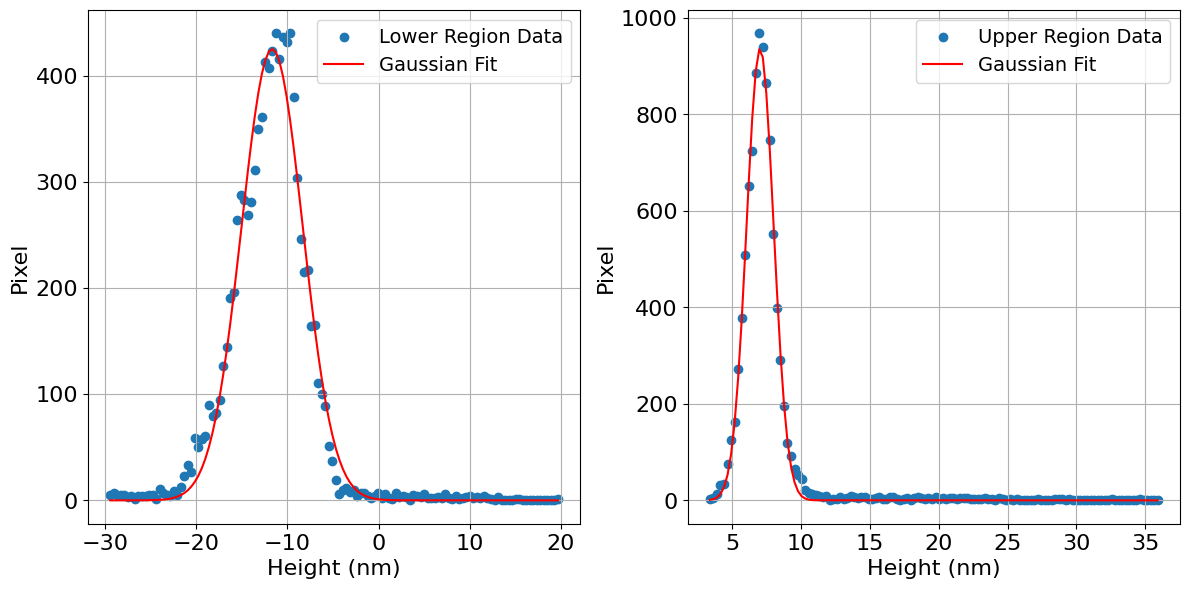

VPPC: 50, Mean Difference: 28.36985235645051, Std Difference: 2.05120497077976


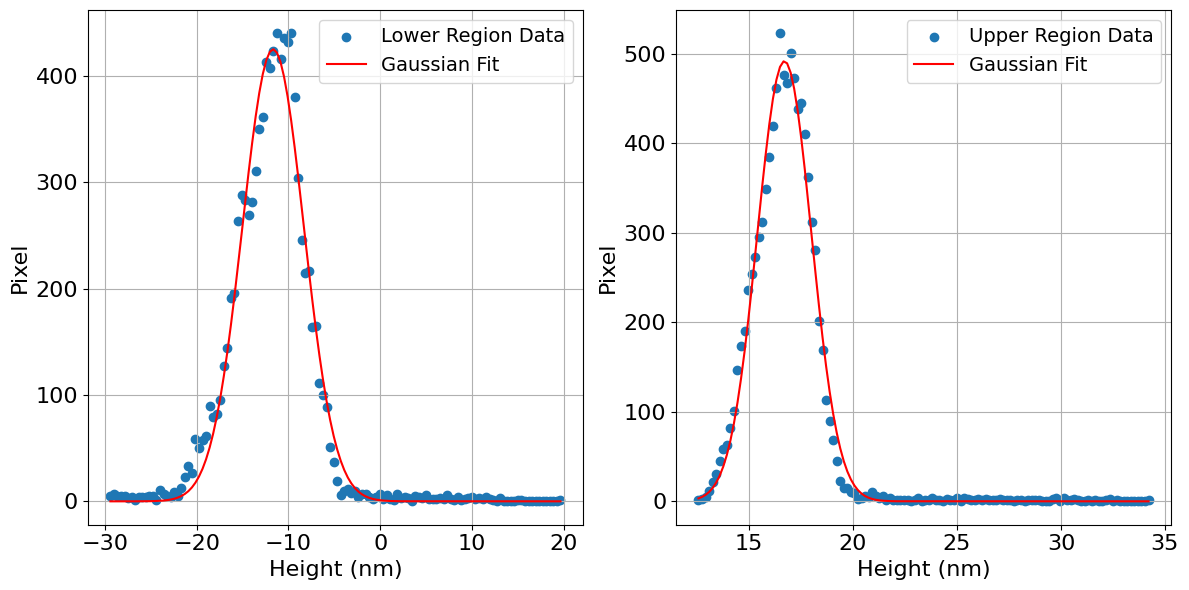

VPPC: 60, Mean Difference: 7.1869811922010935, Std Difference: 0.6982610632339203


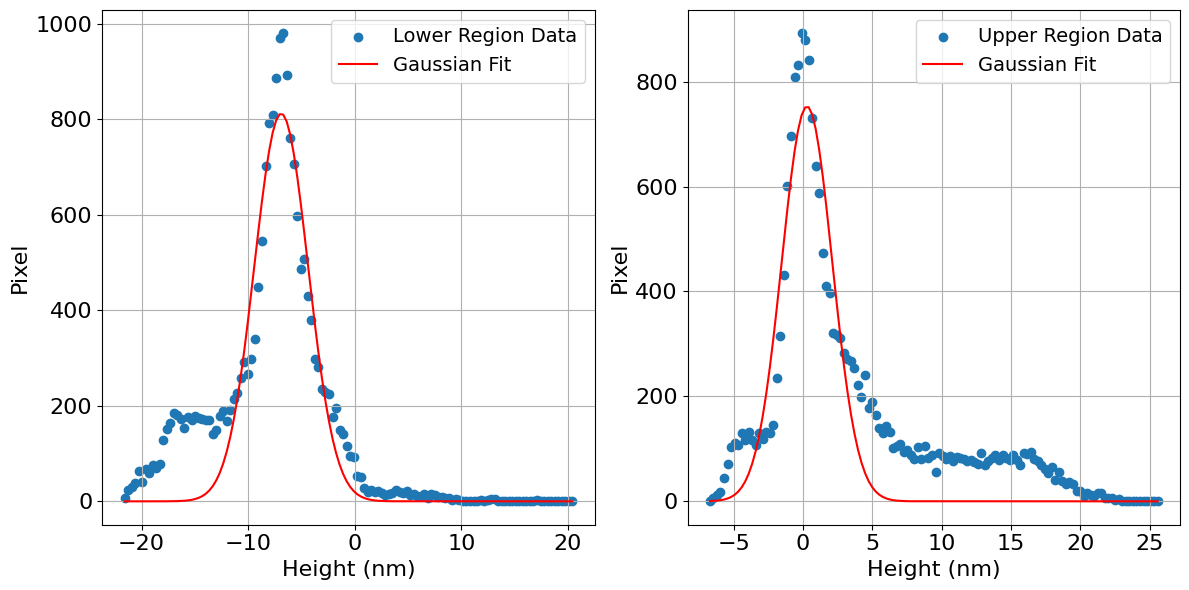

VPPC: 60, Mean Difference: 8.584861397838734, Std Difference: 4.888314761026668


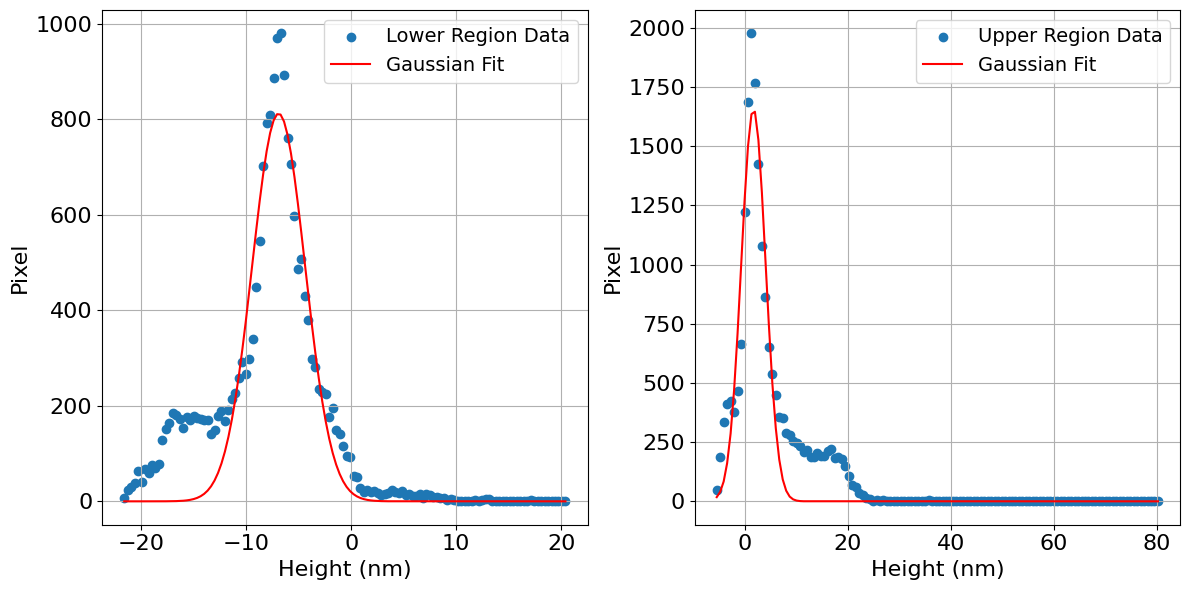

VPPC: 70, Mean Difference: 3.5655446218638773, Std Difference: 2.4446408156288912


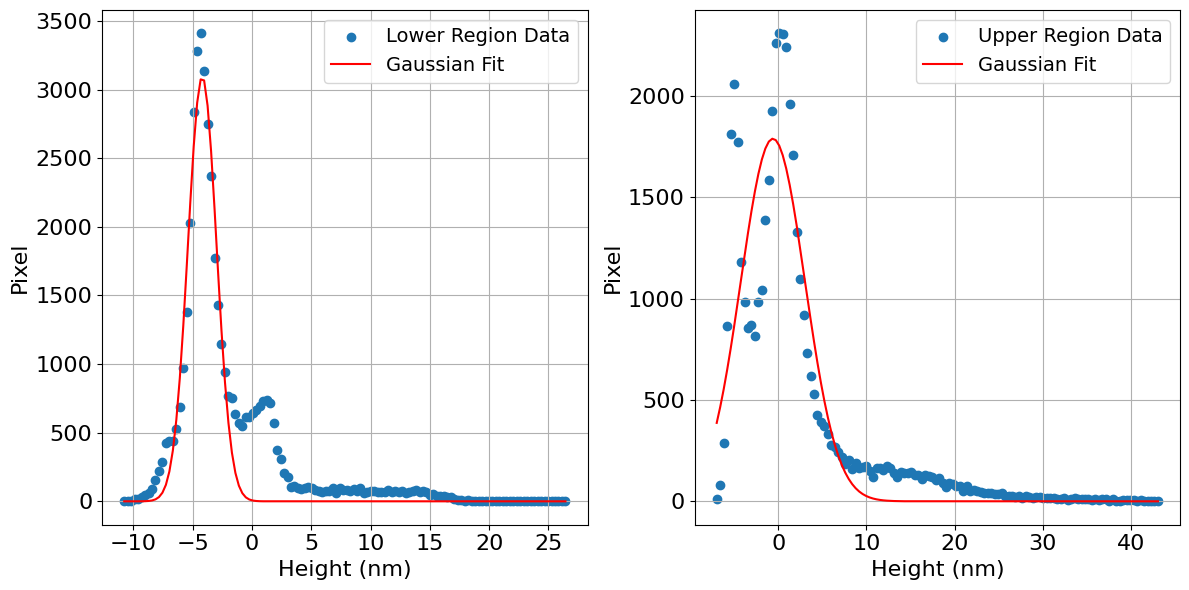

VPPC: 70, Mean Difference: 4.634130211733808, Std Difference: 0.38752908552146903


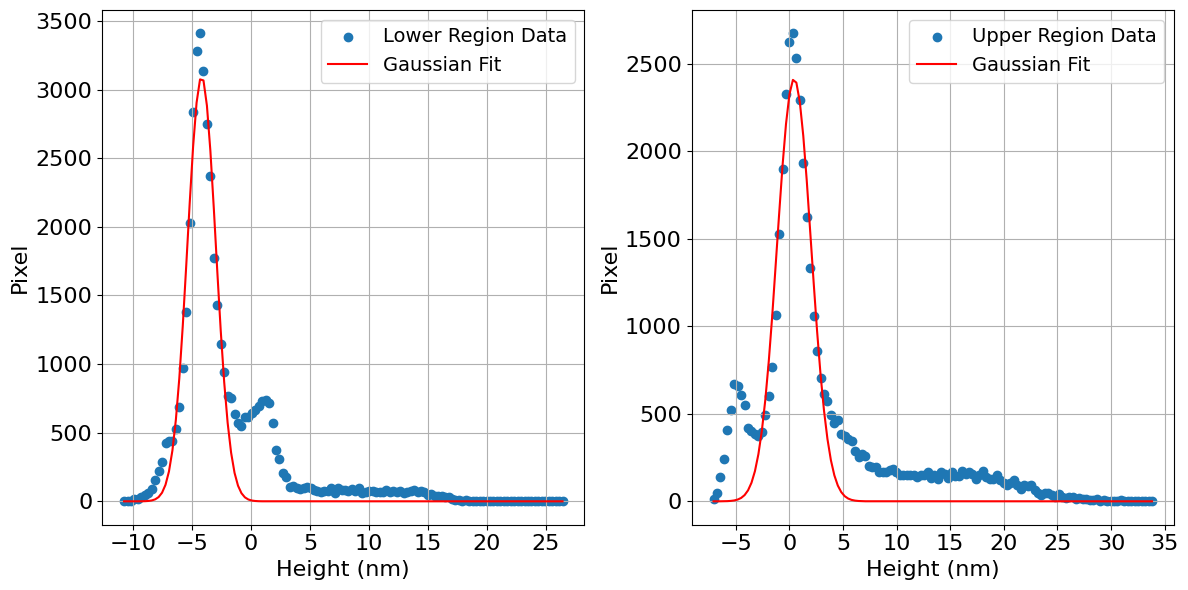

VPPC: 80, Mean Difference: 12.923474974368757, Std Difference: 6.837313684464167


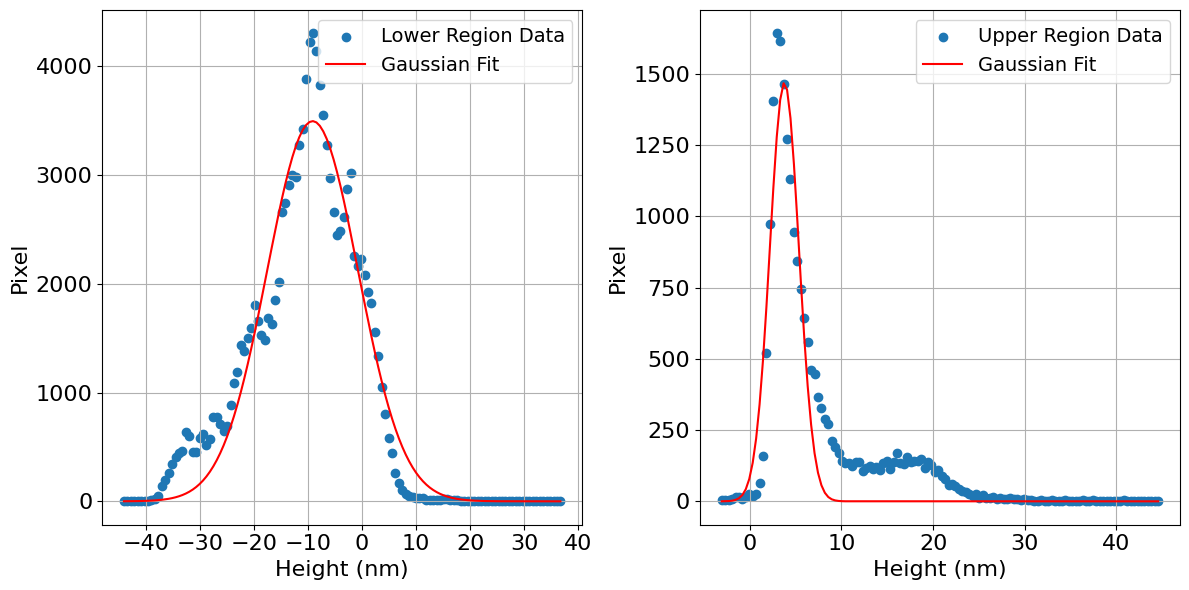

VPPC: 80, Mean Difference: 15.523095247032018, Std Difference: 7.61098399783186


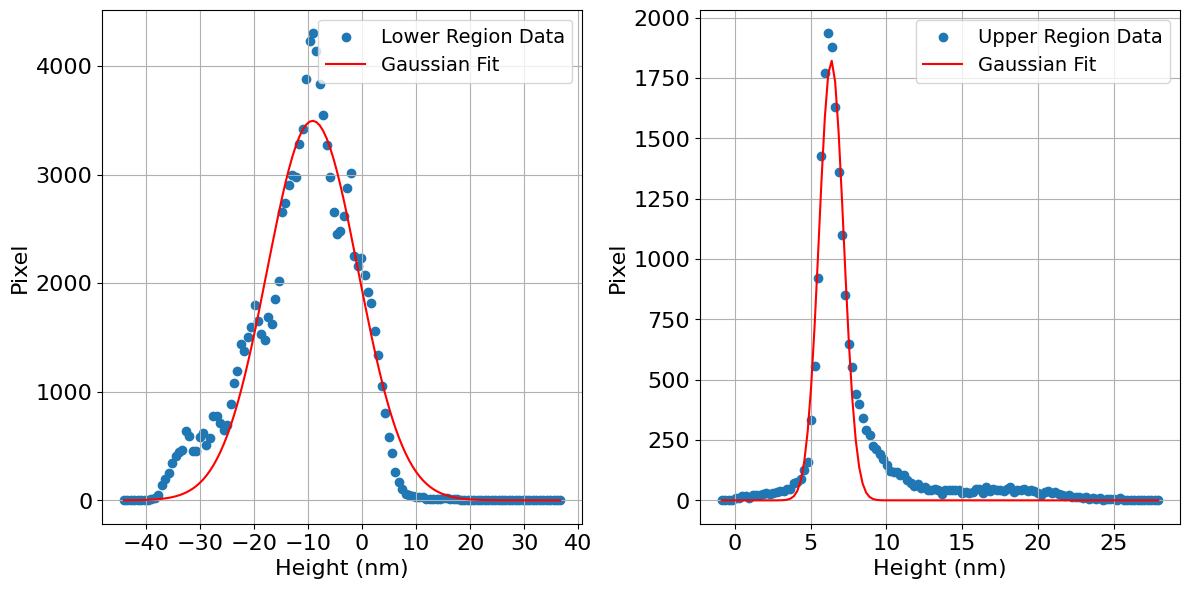

VPPC: 90, Mean Difference: 3.031765505629375, Std Difference: 0.33269882667511497


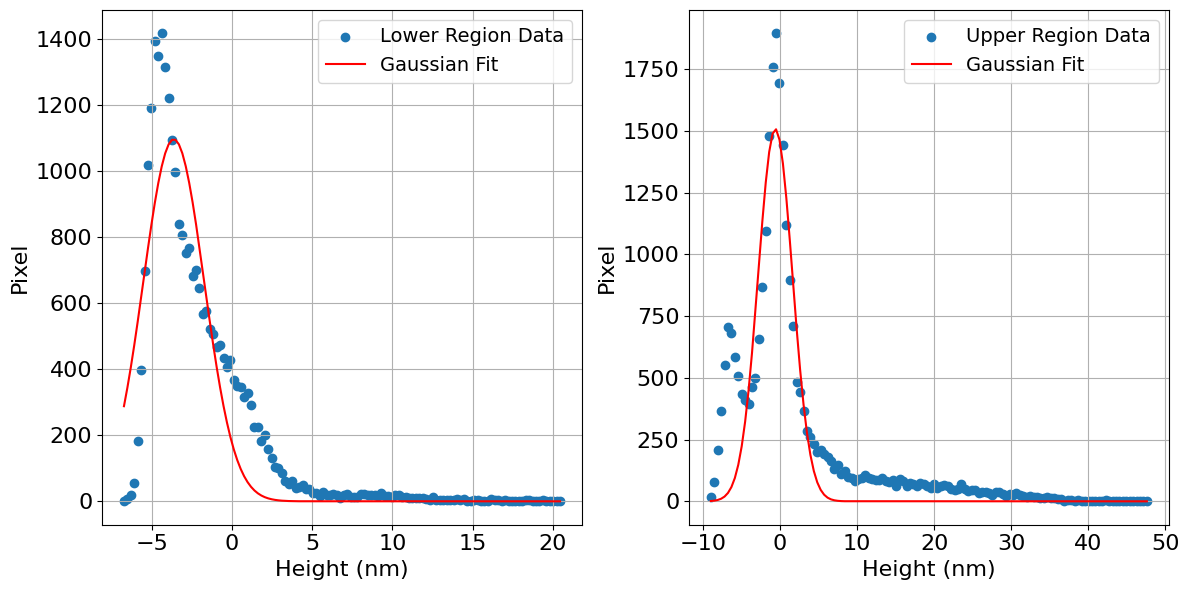

VPPC: 90, Mean Difference: 3.559014987826988, Std Difference: 2.4183104528842465


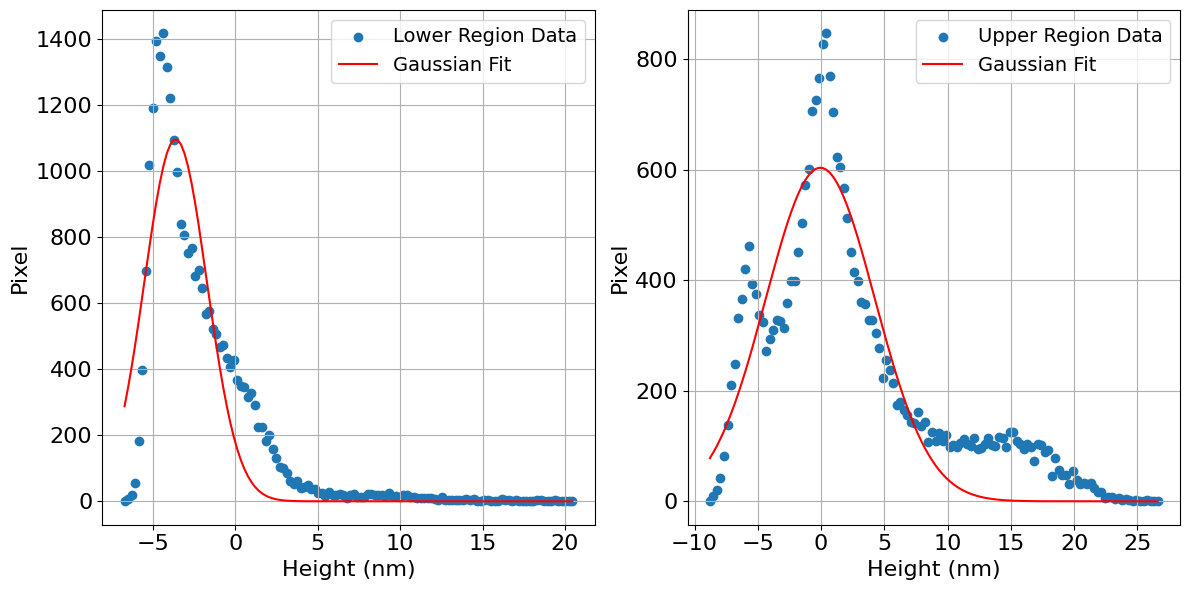

In [26]:
PPCDATA['20_1'].process()
PPCDATA['20_2'].process()
PPCDATA['30_1'].process()
PPCDATA['30_2'].process()
PPCDATA['40_1'].process()
PPCDATA['40_2'].process()
PPCDATA['50_1'].process()
PPCDATA['50_2'].process()
PPCDATA['60_1'].process()
PPCDATA['60_2'].process()
PPCDATA['70_1'].process()
PPCDATA['70_2'].process()
PPCDATA['80_1'].process()
PPCDATA['80_2'].process()
PPCDATA['90_1'].process()
PPCDATA['90_2'].process()

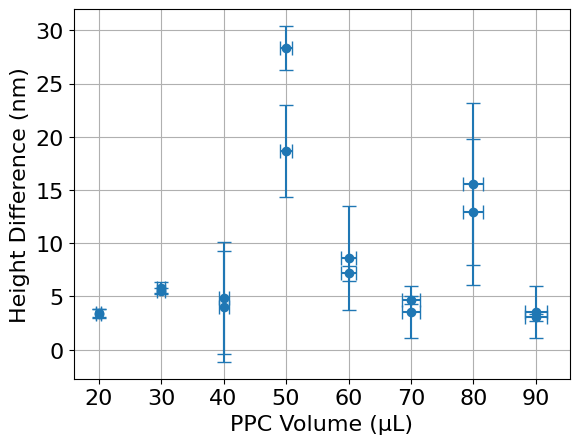

In [27]:
# Plot mean height difference and std difference as error bars against VPPC
import matplotlib.pyplot as plt

VPPCs = []
mean_diffs = []
std_diffs = []
for vppc, hd in PPCDATA.items():
    VPPCs.append(float(hd.VPPC))
    mean_diffs.append(hd.meandiff['mean'])
    std_diffs.append(hd.meandiff['std'])

plt.errorbar(VPPCs, mean_diffs, xerr=np.multiply(0.02, VPPCs), yerr=std_diffs, fmt='o', capsize=5, label='Mean Height')
plt.xlabel('PPC Volume (µL)', fontsize=16)
plt.ylabel('Height Difference (nm)', fontsize=16)
plt.grid(True)
plt.xticks(np.arange(min(VPPCs), max(VPPCs)+1, 10), fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('mean_height.png', dpi=600)
plt.show()